## Sample level representation of the dataset

In [1]:
import scanpy as sc
import decoupler as dc
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

# making sure plots & clusters are reproducible
np.random.seed(42)

/home/niklas/miniconda3/envs/niche_fibrosis_env_decoupleR/lib/python3.9/site-packages/setuptools_scm/_integration/setuptools.py:31: RuntimeWarning: 
ERROR: setuptools==59.8.0 is used in combination with setuptools_scm>=8.x

Your build configuration is incomplete and previously worked by accident!
setuptools_scm requires setuptools>=61

Suggested workaround if applicable:
 - migrating from the deprecated setup_requires mechanism to pep517/518
   and using a pyproject.toml to declare build dependencies
   which are reliably pre-installed before running the build tools

  warnings.warn(
/home/niklas/miniconda3/envs/niche_fibrosis_env_decoupleR/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running Scanpy 1.8.2, on 2024-08-14 17:59.


In [2]:
## path variables
adata_dir = '/mnt/smb2/Niklas/GLPG_data_temp/240811_GLPG_annotated.h5ad'
data_dir = '/home/niklas/projects/GLPG_drug_perturbations/01_data/'
out_dir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig1/'

In [3]:
## plotting variables
sc.settings.figdir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig1/'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## load anndata object
adata = sc.read(adata_dir)

/home/niklas/miniconda3/envs/niche_fibrosis_env_decoupleR/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [5]:
## have a look at the adata object: 442k cells x 25194 genes
adata

AnnData object with n_obs × n_vars = 442439 × 24500
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2', 'cell_type', 'group', 'ashcroft_score', 'body_weight_d0', 'body_weight_d1', 'body_weight_d2', 'body_weight_d3', 'body_weight_d4', 'body_weight_d5', 'body_weight_d6', 'body_weight_d7', 'body_weight_d8', 'body_weight_d9', 'body_weight_d10', 'body_weight_d11', 'body_weight_d12', 'body_weight_d13', 'body_weight_d14', 'body_weight_d15', 'body_weight_d16', 'body_weight_d17', 'body_weight_d18', 'body_weight_d19', 'body_weight_d20', 'body_weight_d21', 'body_weight_min', 'body_weight_max', 'delta_max_body_weight', 'delta_body_weight_d7_10', 'delta_body_weight_d14_d21'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nba

In [6]:
# Get pseudo-bulk profile
pdata = dc.get_pseudobulk(
    adata,
    sample_col='identifier',
    groups_col=None, #only necessary for pseudobulk DGE testing
    layer='counts',
    mode='sum',
    min_cells=1,
    min_counts=1
)

In [7]:
pdata

AnnData object with n_obs × n_vars = 108 × 24500
    obs: 'identifier', 'time_point', 'treatment_time', 'treatment', 'sample_name', 'condition', 'psbulk_n_cells', 'psbulk_counts'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    layers: 'psbulk_props'

In [8]:
## create new meta data column and set to 'nan'
pdata.obs['body_weight_d0'] = np.nan
pdata.obs['body_weight_d10'] = np.nan
pdata.obs['body_weight_d21'] = np.nan
pdata.obs['body_weight_min'] = np.nan
pdata.obs['delta_max_body_weight'] = np.nan
pdata.obs['ashcroft_score'] = np.nan

In [9]:
metadata = pd.read_csv(data_dir + '20201117_GLPG_metadata.csv', sep=',', index_col = 'identifier')
metadata.head(5)

,group,time_point,ashcroft_score,body_weight_d0,body_weight_d1,body_weight_d2,body_weight_d3,body_weight_d4,body_weight_d5,body_weight_d6,...,body_weight_d17,body_weight_d18,body_weight_d19,body_weight_d20,body_weight_d21,body_weight_min,body_weight_max,delta_max_body_weight,delta_body_weight_d7_10,delta_body_weight_d14_d21
identifier,,,,,,,,,,,,,,,,,,,,,
d10BLM_Combo39,BLM_Combo,d10,2.2500,23.5,22.3,22.4,22.9,22.8,22.2,21.5,...,NaN,NaN,NaN,NaN,NaN,21.0,23.5,-2.5,-2.5,NaN
d10BLM_Combo41,BLM_Combo,d10,2.5625,23.8,22.4,23.4,23.7,23.6,23.2,23.4,...,NaN,NaN,NaN,NaN,NaN,22.4,24.0,-1.4,-0.5,NaN
d10BLM_Combo42,BLM_Combo,d10,2.6875,24.6,24.1,24.0,24.4,23.5,22.0,22.5,...,NaN,NaN,NaN,NaN,NaN,22.0,24.6,-2.6,-1.4,NaN
d10BLM_Combo43,BLM_Combo,d10,1.7500,25.8,25.3,24.8,25.1,25.4,24.2,23.9,...,NaN,NaN,NaN,NaN,NaN,23.0,25.8,-2.8,-2.8,NaN
d10BLM_Combo44,BLM_Combo,d10,1.5625,23.5,23.0,22.9,22.9,23.2,23.8,24.0,...,NaN,NaN,NaN,NaN,NaN,22.9,24.5,-0.6,0.2,NaN


In [10]:
## retrieve metadata from adata to add to pdata
pdata.obs['body_weight_d0'].update(pd.Series(metadata['body_weight_d0'].values, name = 'body_weight_d0', index = metadata.index))
pdata.obs['body_weight_d10'].update(pd.Series(metadata['body_weight_d10'].values, name = 'body_weight_d10', index = metadata.index))
pdata.obs['body_weight_d21'].update(pd.Series(metadata['body_weight_d21'].values, name = 'body_weight_d21', index = metadata.index))
pdata.obs['body_weight_min'].update(pd.Series(metadata['body_weight_min'].values, name = 'body_weight_min', index = metadata.index))
pdata.obs['delta_max_body_weight'].update(pd.Series(metadata['delta_max_body_weight'].values, name = 'delta_max_body_weight', index = metadata.index))
pdata.obs['ashcroft_score'].update(pd.Series(metadata['ashcroft_score'].values, name = 'ashcroft_score', index = metadata.index))

In [11]:
# Store raw counts in layers
pdata.layers['counts'] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.swap_layer(pdata, 'counts', X_layer_key=None, inplace=True)

normalizing counts per cell
    finished (0:00:00)
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:00)


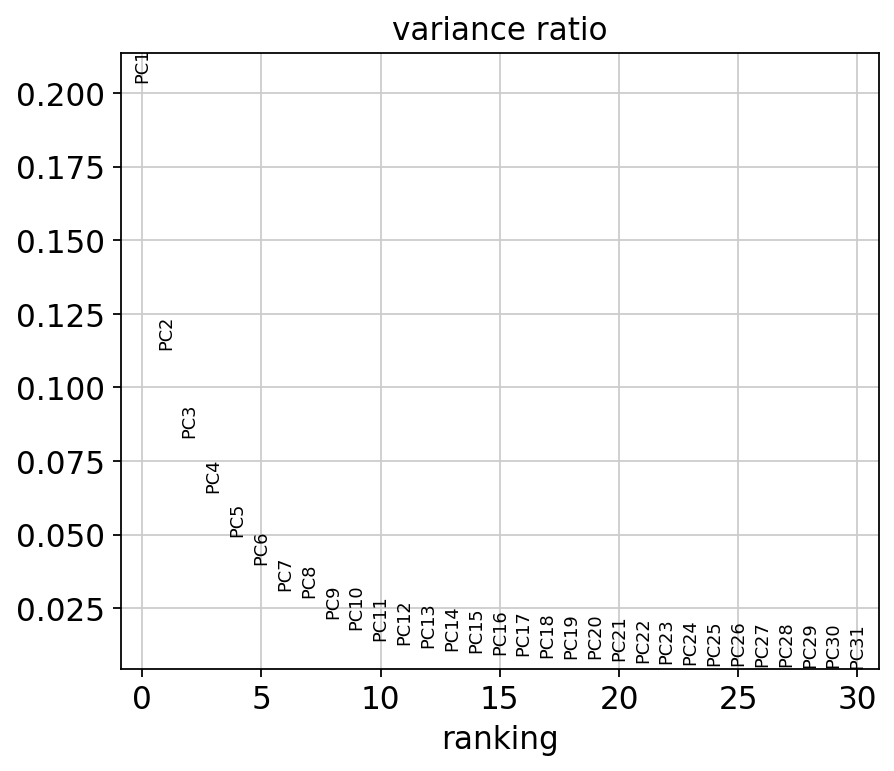

In [12]:
## ellbow plot
sc.pl.pca_variance_ratio(pdata)

In [13]:
## use consistent colormaps for PCA plots
treatment_colors = ['#D3D3D3', '#606060', '#2E59A8', '#C93333', '#FFA500', '#20B2AA']
condition_colors = ['#1A237E', '#FFAB91']
timepoint_colors = ['#6A1B9A', '#FFD700']
treatment_time_colors =  [
    '#D3D3D3', '#A9A9A9',  # Light Grey Pair
    '#606060', '#202020',  # Dark Grey Pair
    '#2E59A8', '#1A3B6F',  # Blue Pair
    '#C93333', '#8B2323',  # Red Pair
    '#FFA500', '#CC7000',  # Orange Pair
    '#20B2AA', '#006D6D'   # Teal Pair
]

In [14]:
## rename treatmentlabel
treatment_conversion = {'none' : 'PBS',
                        'vehicle' : 'Bleo',
                        'Nintedanib' : 'Bleo+Nintedanib',
                        'GLPG1205' : 'Bleo+GLPG1205',
                        'GLPG1690' : 'Bleo+GLPG1690',
                        'Combo' : 'Bleo+Combo'
}
pdata.obs['treatment'] = [treatment_conversion[tt] for tt in pdata.obs['treatment']]

In [15]:
pdata.obs['treatment'] = pdata.obs['treatment'].astype('category')
pdata.obs['treatment'] = pdata.obs['treatment'].cat.reorder_categories(['PBS',
                                                                         'Bleo',
                                                                         'Bleo+Nintedanib',
                                                                         'Bleo+GLPG1690',
                                                                         'Bleo+GLPG1205',
                                                                         'Bleo+Combo'])

/home/niklas/miniconda3/envs/niche_fibrosis_env_decoupleR/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


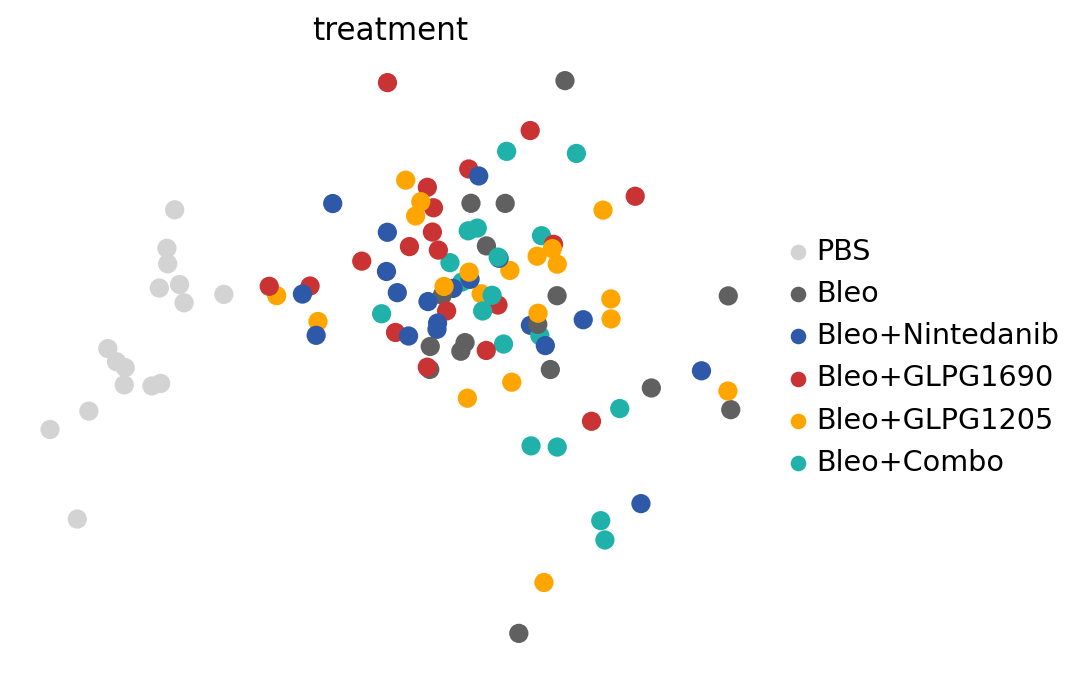

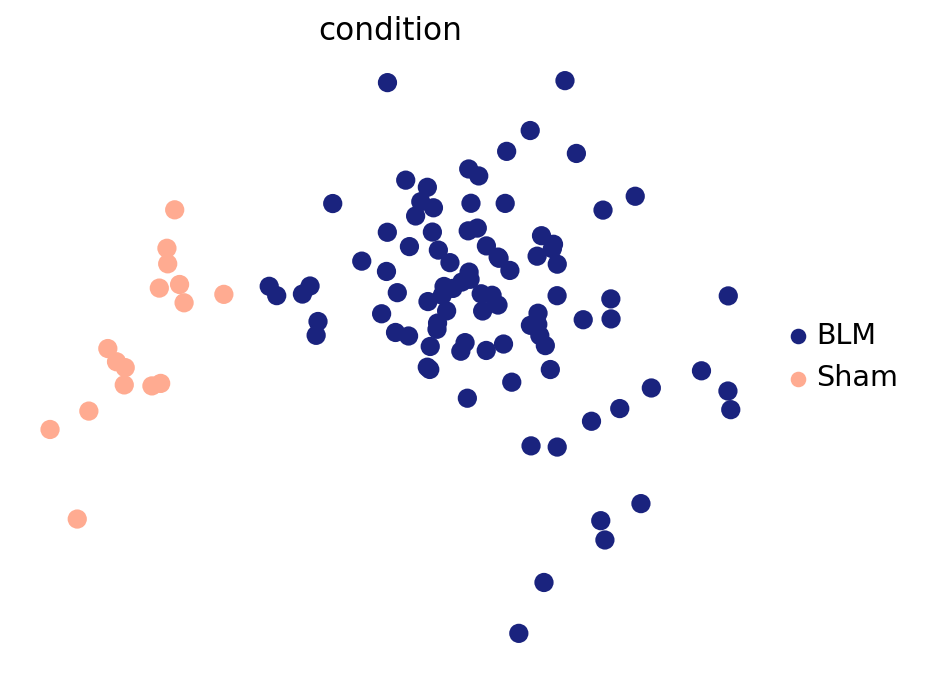

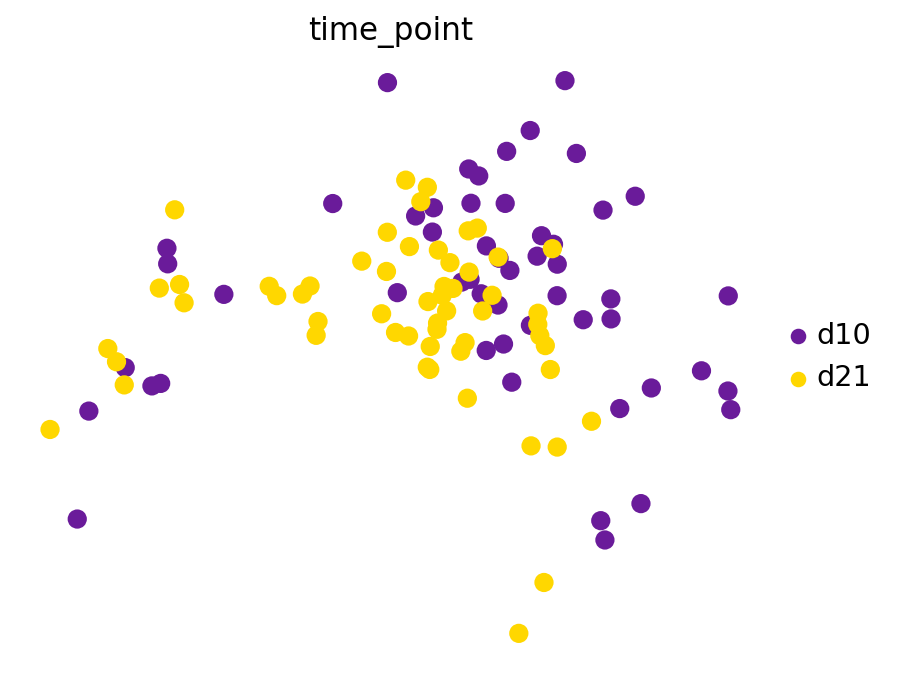

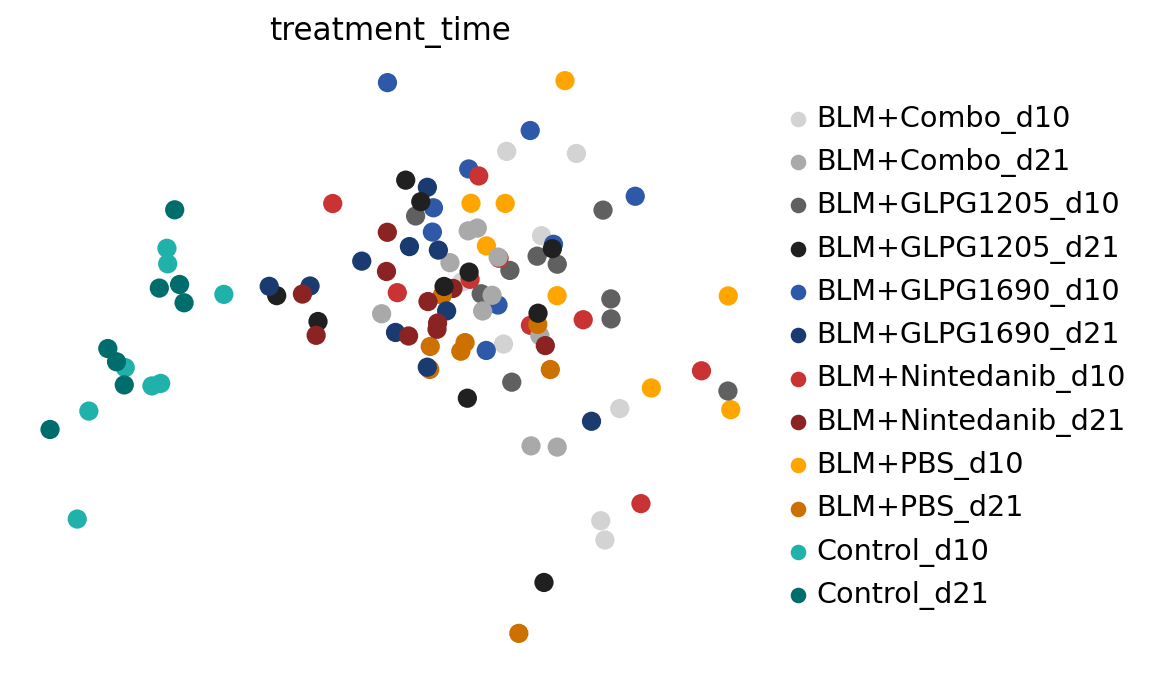

In [16]:
## standard PCA plots (categorical variables only)
###
sc.pl.pca(pdata, color = ['treatment'], palette = treatment_colors, size=300, frameon = False, save = '_treatment.pdf')
###
sc.pl.pca(pdata, color = ['condition'], palette = condition_colors, size=300, frameon = False, save = '_condition.pdf')
###
sc.pl.pca(pdata, color = ['time_point'], palette = timepoint_colors, size=300, frameon = False, save = '_time_point.pdf')
###
sc.pl.pca(pdata, color = ['treatment_time'], palette = treatment_time_colors, size=300, frameon = False, save = '_treatment_time.pdf')

In [17]:
## create a bit more fancy color map for disease severity!
from matplotlib.colors import LinearSegmentedColormap
severity = LinearSegmentedColormap.from_list(
    "Grey-Orange-Red", ["#D3D3D3", "#FFA500", "#8B0000"]
)
severity_r = LinearSegmentedColormap.from_list(
    "Grey-Orange-Red", ["#8B0000", "#FFA500", "#D3D3D3"]
)

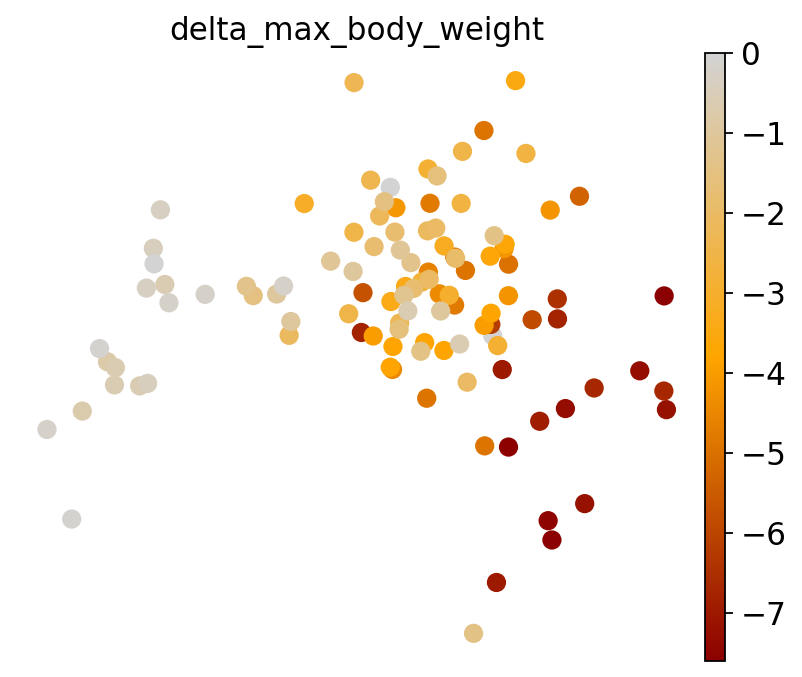

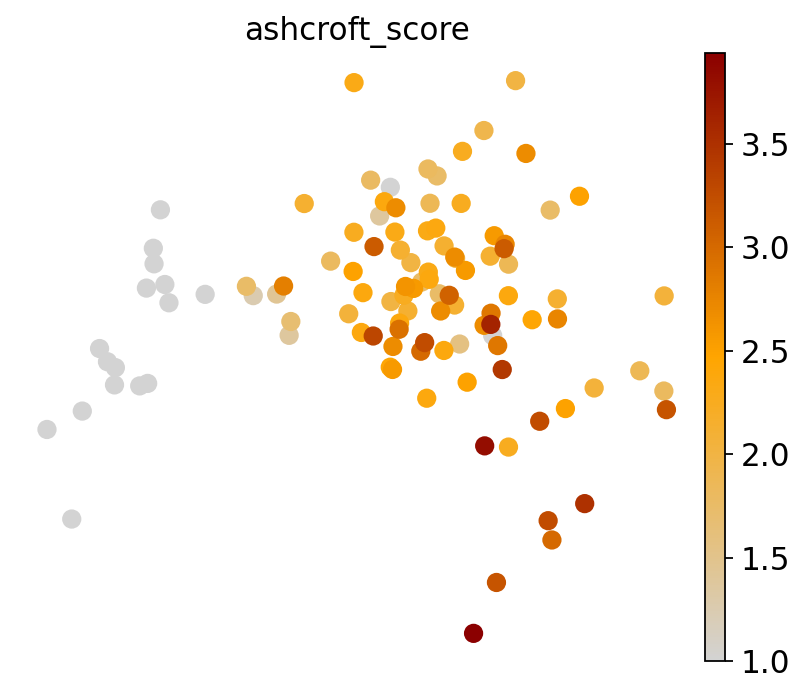

In [18]:
###
sc.pl.pca(pdata, color = ['delta_max_body_weight'], color_map = severity_r, size=300, frameon = False, save = '_delta_max_body_weight.pdf')
###
sc.pl.pca(pdata, color = ['ashcroft_score'], color_map = severity, size=300, frameon = False, save = '_ashcroft_score.pdf')

In [19]:
pdata = pdata[-pdata.obs['ashcroft_score'].isna()]

In [20]:
pdata.obs['ashcroft_score'] = pdata.obs['ashcroft_score'].astype('float')
pdata.obs['delta_max_body_weight'] = pdata.obs['delta_max_body_weight'].astype('float')

/var/tmp/ipykernel_1093570/3146411856.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  pdata.obs['ashcroft_score'] = pdata.obs['ashcroft_score'].astype('float')


In [21]:
## restructure metadata
dc.get_metadata_associations(
    pdata,
    obs_keys = ['treatment', 'time_point','treatment_time', 'delta_max_body_weight','ashcroft_score','psbulk_counts'],  # Metadata columns to associate to PCs
    obsm_key='X_pca',  # Where the PCs are stored
    uns_key='pca_anova',  # Where the results are stored
    inplace=True,
)

In [37]:
## circumnavigate decoupleR's color map requirements (must be string)
treatment_colors = {
    'PBS': '#D3D3D3',
    'Bleo': '#606060',
    'Bleo+Nintedanib': '#2E59A8',
    'Bleo+GLPG1690': '#C93333',
    'Bleo+GLPG1205': '#FFA500',
    'Bleo+Combo': '#20B2AA'
}

# Create a color map function
def map_colors(data, color_dict):
    return data.map(color_dict)

# Map treatments to colors
pdata.obs['treatment_colors'] = pdata.obs['treatment'].map(treatment_colors)

# Convert this to a categorical type, ensuring correct plotting
pdata.obs['treatment_colors'] = pd.Categorical(pdata.obs['treatment_colors'], categories=treatment_colors.values())

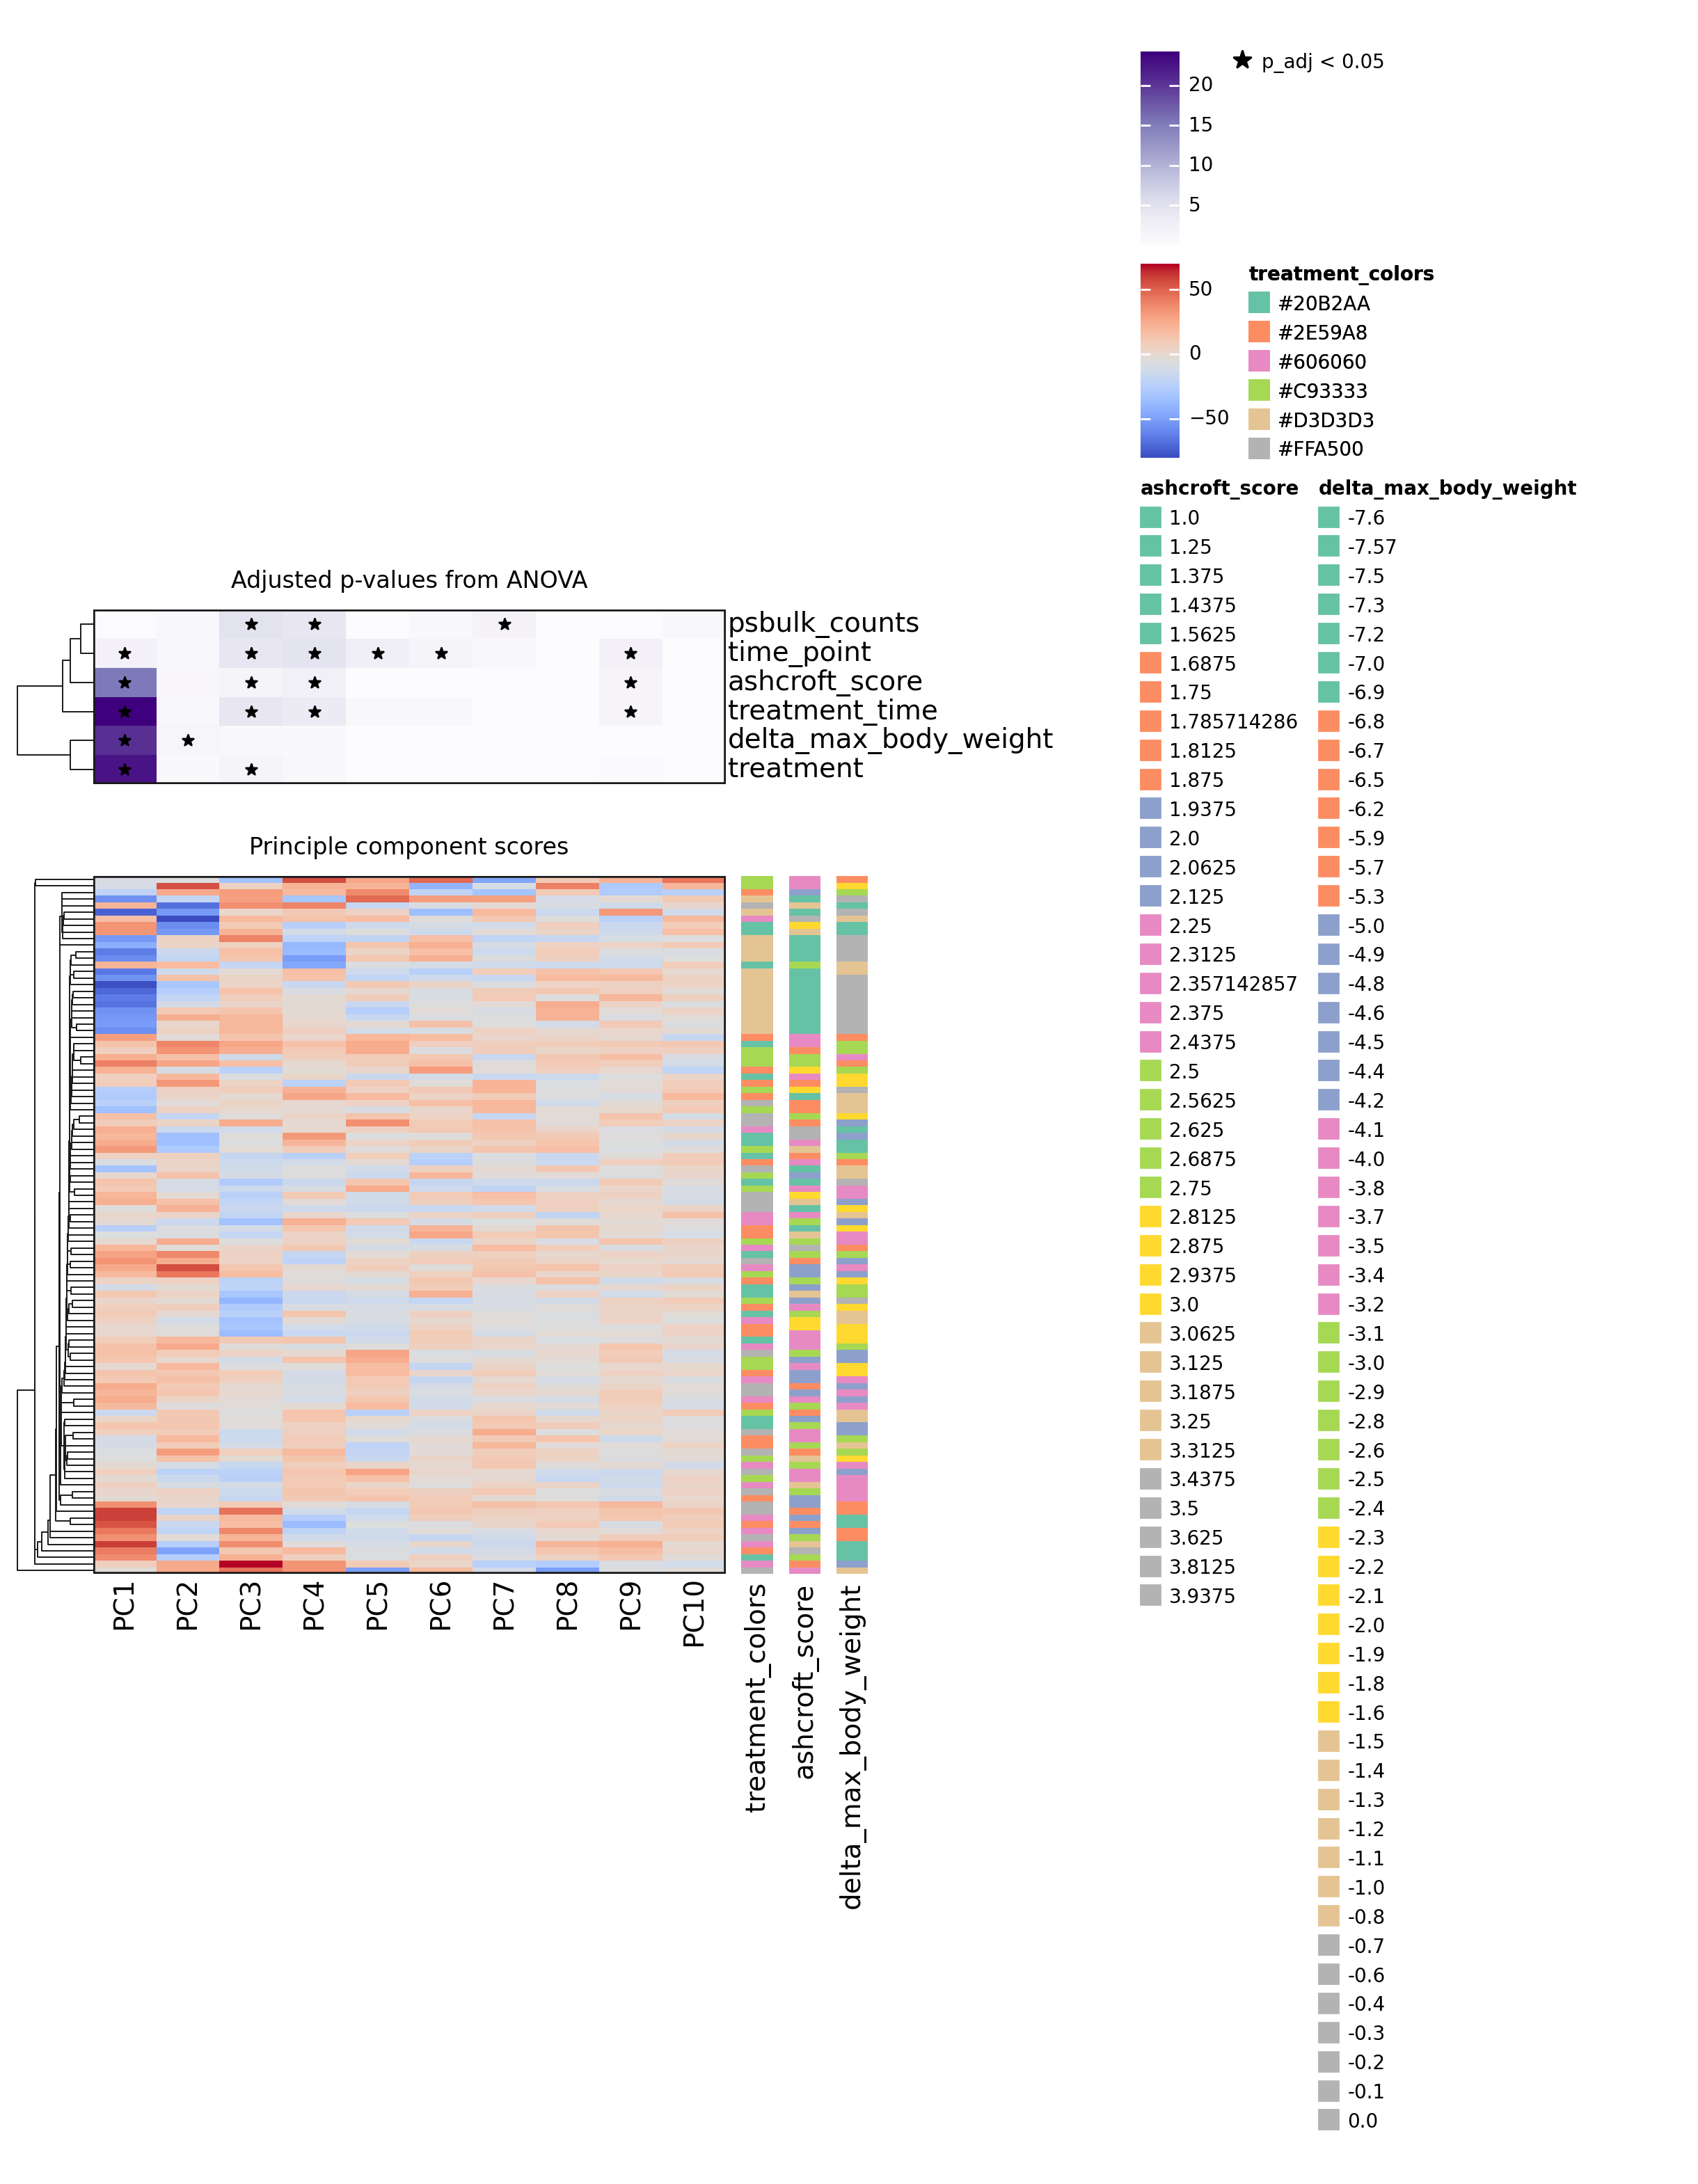

In [38]:
## sample level PC - ANOVA heatmap
dc.plot_associations(
    pdata,
    uns_key='pca_anova',  # Summary statistics from the anova tests
    obsm_key='X_pca',  # where the PCs are stored
    stat_col='p_adj',  # Which summary statistic to plot
    obs_annotation_cols = ['treatment_colors','ashcroft_score', 'delta_max_body_weight'], # which sample annotations to plot
    cmap_scores='coolwarm',
    #cmap_cats = treatment_cmap,
    titles=['Principle component scores', 'Adjusted p-values from ANOVA'],
    figsize=(12, 8),
    n_factors=10
    #save = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig1/pca_heatmap.pdf'
)